<a href="https://colab.research.google.com/github/chanikyaramireddy/Open-CV-record/blob/main/exp11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving monarch-butterfly-2.jpg to monarch-butterfly-2.jpg


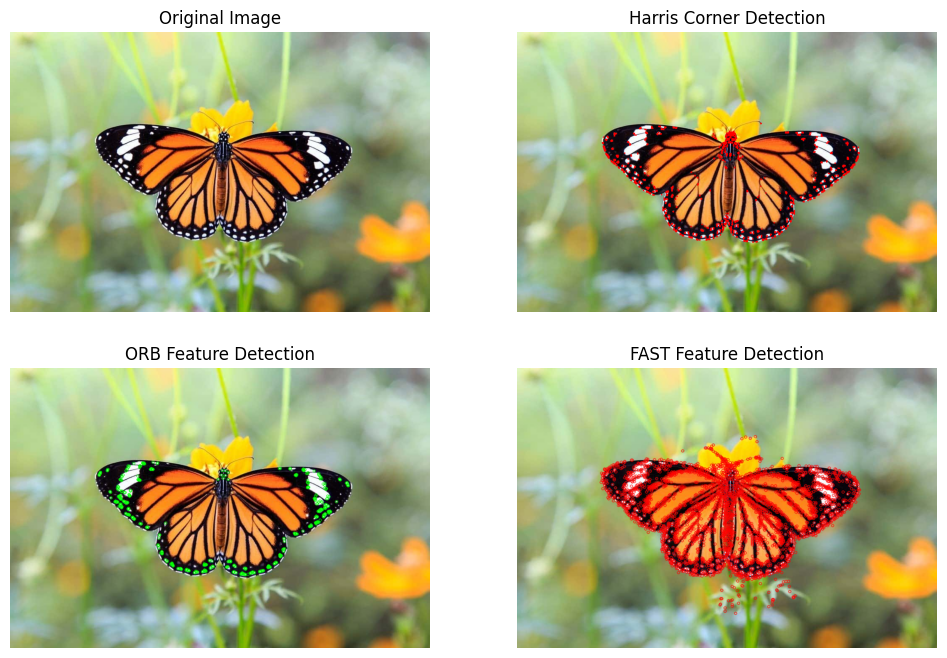

ORB keypoints: 500
FAST keypoints: 3197


In [1]:
# Install OpenCV (if not already available)
!pip install opencv-python-headless

# Import libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Upload image
from google.colab import files
uploaded = files.upload()

# Read image
image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------------------------
# 1. Harris Corner Detection
# ---------------------------
gray_float = np.float32(gray)
harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Dilate to mark corners
harris = cv2.dilate(harris, None)

harris_img = img_rgb.copy()
harris_img[harris > 0.01 * harris.max()] = [255, 0, 0]  # mark in red

# ---------------------------
# 2. ORB Feature Detection
# ---------------------------
orb = cv2.ORB_create()
kp_orb = orb.detect(gray, None)
kp_orb, des_orb = orb.compute(gray, kp_orb)

orb_img = cv2.drawKeypoints(img_rgb, kp_orb, None, color=(0,255,0), flags=0)

# ---------------------------
# 3. FAST Feature Detection
# ---------------------------
fast = cv2.FastFeatureDetector_create()
kp_fast = fast.detect(gray, None)

fast_img = cv2.drawKeypoints(img_rgb, kp_fast, None, color=(255,0,0))

# ---------------------------
# Display Results
# ---------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(harris_img)
plt.title("Harris Corner Detection")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(orb_img)
plt.title("ORB Feature Detection")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(fast_img)
plt.title("FAST Feature Detection")
plt.axis('off')

plt.show()

# Print number of detected features
print("ORB keypoints:", len(kp_orb))
print("FAST keypoints:", len(kp_fast))